# Task 9: Spam detector

Classify SMS messages as spam or ham (not spam) using TF-IDF and a linear SVM.
Dataset: SMS Spam Collection (`data/sms_spam.tsv`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## 1. Load the data

In [2]:
df = pd.read_csv("data/sms_spam.tsv", sep="\t", header=None, names=["label", "text"])
print(df.shape)
print(df["label"].value_counts())
df.head()

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Only about 13% of the messages are spam, so accuracy alone is not a good metric
(a model that always says "ham" would get 87%). I will also look at precision, recall and F1 for spam.

The data has duplicate messages. I remove them before splitting, otherwise the same message can be in both train and test.

In [3]:
print("duplicates:", df["text"].duplicated().sum())
df = df.drop_duplicates(subset="text").reset_index(drop=True)
df["spam"] = (df["label"] == "spam").astype(int)
print(df.shape)

duplicates: 403
(5169, 3)


## 2. Train / test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["spam"], test_size=0.2, stratify=df["spam"], random_state=42)
print(len(X_train), len(X_test))

4135 1034


## 3. TF-IDF + SVM

TF-IDF converts each message into numbers. Words that appear often in a message but are rare in the other messages get a high score.
I use single words and pairs of words, and remove english stop words. LinearSVC is the SVM classifier.
`class_weight="balanced"` is used because there are fewer spam messages.

In [5]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("svm", LinearSVC(class_weight="balanced", random_state=42)),
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a se

## 4. Evaluation

In [6]:
pred = model.predict(X_test)
print("accuracy:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, target_names=["ham", "spam"]))

accuracy: 0.9797
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.94      0.90      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



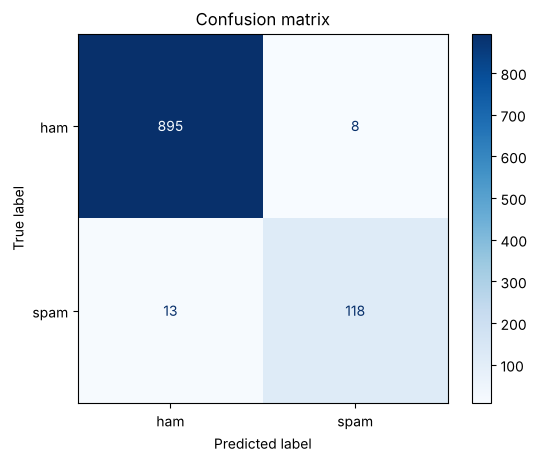

In [7]:
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

Messages the model got wrong:

In [8]:
wrong = pd.DataFrame({"text": X_test.values, "actual": y_test.values, "predicted": pred})
pd.set_option("display.max_colwidth", 120)
wrong[wrong.actual != wrong.predicted].head(10)

,text,actual,predicted
29,Your daily text from me – a favour this time,0,1
95,Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX,1,0
105,You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750,1,0
168,Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 J...,1,0
230,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT....,1,0
293,Are you free now?can i call now?,0,1
301,"Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/SMS PIN thru ema...",0,1
308,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 0909972639...,1,0
326,Missed call alert. These numbers called but left no message. 07008009200,1,0
327,K k:) sms chat with me.,0,1


## 5. Which words matter?

In [9]:
words = np.array(model.named_steps["tfidf"].get_feature_names_out())
weights = model.named_steps["svm"].coef_[0]
order = np.argsort(weights)
print("spam words:", list(words[order[-15:]][::-1]))
print("ham words :", list(words[order[:15]]))

spam words: ['txt', 'uk', '50', 'mobile', 'www', 'talk time', '150p', 'services', 'claim', 'won', 'arsenal', 'video', 'com', 'reply', 'http']
ham words : ['home', 'ok', 'mail', 'later', 'hey', 'way', 'lol', 'yup', 'lt', 'pa', 'liked', 'new number', 'morphine', 'sure', 'didn']


## 6. Try it on new messages

In [10]:
messages = [
    "WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461 now to claim.",
    "Hey, are we still meeting for lunch at 1pm today?",
    "Congratulations! Free entry to win a brand new iPhone. Text WIN to 80082 now",
    "Can you send me the notes from yesterday's lecture? I missed the last 20 minutes",
    "URGENT! Your account has been suspended. Click http://bit.ly/verify to claim your free gift",
    "Mom said dinner will be ready by 8, don't be late",
    "You have won a 1000 cash prize! To claim call 08712300220 before it expires",
    "I'll call you after the class, my phone battery is dying",
]
scores = model.decision_function(messages)
for m, s in zip(messages, scores):
    print("SPAM" if s > 0 else "ham ", round(s, 2), "|", m)

SPAM 0.91 | WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461 now to claim.
ham  -1.59 | Hey, are we still meeting for lunch at 1pm today?
SPAM 0.94 | Congratulations! Free entry to win a brand new iPhone. Text WIN to 80082 now
ham  -0.66 | Can you send me the notes from yesterday's lecture? I missed the last 20 minutes
SPAM 1.0 | URGENT! Your account has been suspended. Click http://bit.ly/verify to claim your free gift
ham  -1.33 | Mom said dinner will be ready by 8, don't be late
SPAM 1.42 | You have won a 1000 cash prize! To claim call 08712300220 before it expires
ham  -1.27 | I'll call you after the class, my phone battery is dying


In [11]:
joblib.dump(model, "model/spam_tfidf_svm.joblib")

['model/spam_tfidf_svm.joblib']